# Activity 2 — Perceptron

**Insper · Artificial Neural Networks and Deep Learning · Individual**

This notebook implements a binary perceptron from scratch and trains the **same model** on two datasets: one linearly separable and one with heavily overlapping classes. It is self-contained, uses only NumPy, pandas and Matplotlib, and reproduces the published report from a single `np.random.default_rng(42)`.

In [1]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7.2, 5.0),
    'figure.dpi': 120,
    'font.family': 'DejaVu Serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})
COLORS = ['#2166AC', '#8C510A']
MARKERS = ['o', 's']
rng = np.random.default_rng(42)
print('Single random generator:', rng)

Single random generator: Generator(PCG64)


## Shared implementation

For labels $y,\hat y\in\{0,1\}$, prediction and update are

$$\hat y=\operatorname{step}(\mathbf{w}\cdot\mathbf{x}+b),\qquad \operatorname{step}(z)=\begin{cases}1,&z\geq0\\0,&z<0,\end{cases}$$

$$\mathbf{w}\leftarrow\mathbf{w}+\eta(y-\hat y)\mathbf{x},\qquad b\leftarrow b+\eta(y-\hat y).$$

The equality case belongs to class 1. Accuracy is recorded after every epoch. The pocket is checked after **every mistake-driven update**, so a useful short-lived iterate is not missed.

In [2]:
@dataclass
class TrainingResult:
    weights: np.ndarray
    bias: float
    pocket_weights: np.ndarray
    pocket_bias: float
    pocket_accuracy: float
    pocket_epoch: int
    pocket_update: int
    epochs: int
    accuracy_history: list
    pocket_accuracy_history: list
    updates_history: list
    total_updates: int


def initialize_weights(generator, n_features):
    return generator.normal(0.0, 0.01, size=n_features)


class Perceptron:
    def __init__(self, learning_rate=0.01, max_epochs=100):
        self.learning_rate = float(learning_rate)
        self.max_epochs = int(max_epochs)

    @staticmethod
    def step(scores):
        return (np.asarray(scores) >= 0.0).astype(int)

    @classmethod
    def predict(cls, X, weights, bias):
        return cls.step(np.dot(np.asarray(X), weights) + bias)

    @classmethod
    def accuracy(cls, X, y, weights, bias):
        return float(np.mean(cls.predict(X, weights, bias) == y))

    def fit(self, X, y, initial_weights, initial_bias=0.0):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        weights = np.asarray(initial_weights, dtype=float).copy()
        bias = float(initial_bias)

        pocket_weights = weights.copy()
        pocket_bias = bias
        pocket_accuracy = self.accuracy(X, y, weights, bias)
        pocket_epoch = pocket_update = total_updates = 0
        accuracy_history, pocket_history, updates_history = [], [], []

        for epoch in range(1, self.max_epochs + 1):
            updates = 0
            for xi, target in zip(X, y):
                prediction = int(self.step(weights @ xi + bias).item())
                error = int(target - prediction)
                if error == 0:
                    continue

                weights += self.learning_rate * error * xi
                bias += self.learning_rate * error
                updates += 1
                total_updates += 1

                current_accuracy = self.accuracy(X, y, weights, bias)
                if current_accuracy > pocket_accuracy:
                    pocket_accuracy = current_accuracy
                    pocket_weights = weights.copy()
                    pocket_bias = bias
                    pocket_epoch = epoch
                    pocket_update = total_updates

            accuracy_history.append(self.accuracy(X, y, weights, bias))
            pocket_history.append(pocket_accuracy)
            updates_history.append(updates)
            if updates == 0:
                break

        return TrainingResult(
            weights.copy(), bias, pocket_weights, pocket_bias, pocket_accuracy,
            pocket_epoch, pocket_update, len(accuracy_history),
            accuracy_history, pocket_history, updates_history, total_updates
        )


def scatter_classes(ax, X, y, alpha=0.55):
    for label in (0, 1):
        points = X[y == label]
        ax.scatter(points[:, 0], points[:, 1], s=14, alpha=alpha,
                   color=COLORS[label], marker=MARKERS[label],
                   edgecolors='none', label=f'Class {label}')


def boundary_segment(weights, bias, xlim, ylim, n=300):
    if abs(weights[1]) >= abs(weights[0]):
        xs = np.linspace(*xlim, n)
        ys = -(weights[0] * xs + bias) / weights[1]
    else:
        ys = np.linspace(*ylim, n)
        xs = -(weights[1] * ys + bias) / weights[0]
    visible = ((xs >= xlim[0]) & (xs <= xlim[1]) &
               (ys >= ylim[0]) & (ys <= ylim[1]))
    return xs[visible], ys[visible]

print('Tie prediction step(0):', Perceptron.step(0).item())

Tie prediction step(0): 1


---
## Exercise 1 — Separable data

### A — Generate the data

Each class contains 1,000 points. Class 0 has mean $[1.5,1.5]$ and class 1 has mean $[5,5]$; both use covariance $\operatorname{diag}(0.5,0.5)$.

In [3]:
covariance_1 = np.array([[0.5, 0.0], [0.0, 0.5]])
class_0 = rng.multivariate_normal([1.5, 1.5], covariance_1, size=1000)
class_1 = rng.multivariate_normal([5.0, 5.0], covariance_1, size=1000)
X1 = np.vstack([class_0, class_1])
y1 = np.r_[np.zeros(1000, dtype=int), np.ones(1000, dtype=int)]
print('X shape:', X1.shape, '| class counts:', np.bincount(y1).tolist())

X shape: (2000, 2) | class counts: [1000, 1000]


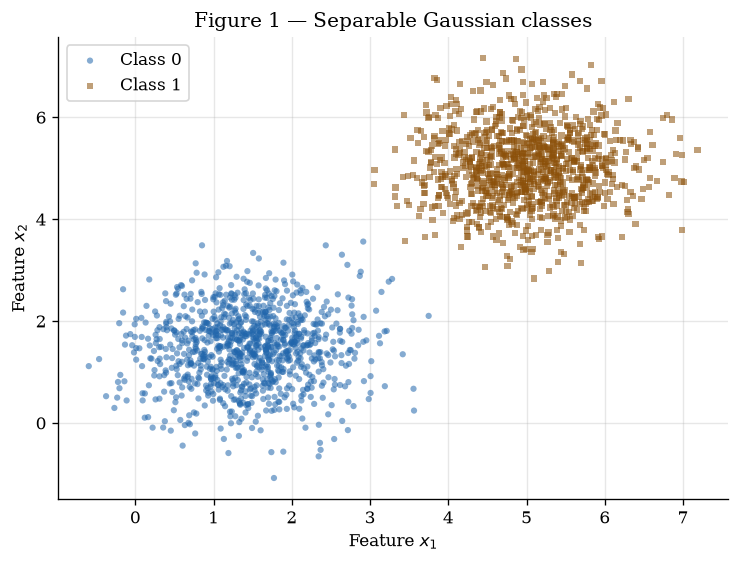

In [4]:
fig, ax = plt.subplots()
scatter_classes(ax, X1, y1)
ax.set(title='Figure 1 — Separable Gaussian classes',
       xlabel=r'Feature $x_1$', ylabel=r'Feature $x_2$')
ax.legend()
plt.show()

### B — Train the perceptron

The initial vector is drawn once from $\mathcal{N}(0,0.01^2)$ and reused for both learning-rate runs. This preserves a fair comparison and consumes no extra random numbers before Exercise 2.

In [5]:
initial_1 = initialize_weights(rng, 2)
result_001 = Perceptron(learning_rate=0.01, max_epochs=100).fit(X1, y1, initial_1)
result_1 = Perceptron(learning_rate=1.0, max_epochs=100).fit(X1, y1, initial_1)

print('Initial weights:', np.round(initial_1, 6))
print('eta=0.01 final weights:', np.round(result_001.weights, 6))
print(f'eta=0.01 bias: {result_001.bias:.6f}')
print(f'Epochs: {result_001.epochs} | accuracy: {result_001.accuracy_history[-1]:.2%}')
print('Updates by epoch:', result_001.updates_history)

Initial weights: [0.002532 0.008952]
eta=0.01 final weights: [0.050497 0.028872]
eta=0.01 bias: -0.250000
Epochs: 26 | accuracy: 100.00%
Updates by epoch: [3, 3, 4, 4, 3, 4, 3, 4, 2, 4, 2, 4, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]


### C — Decision boundary and accuracy

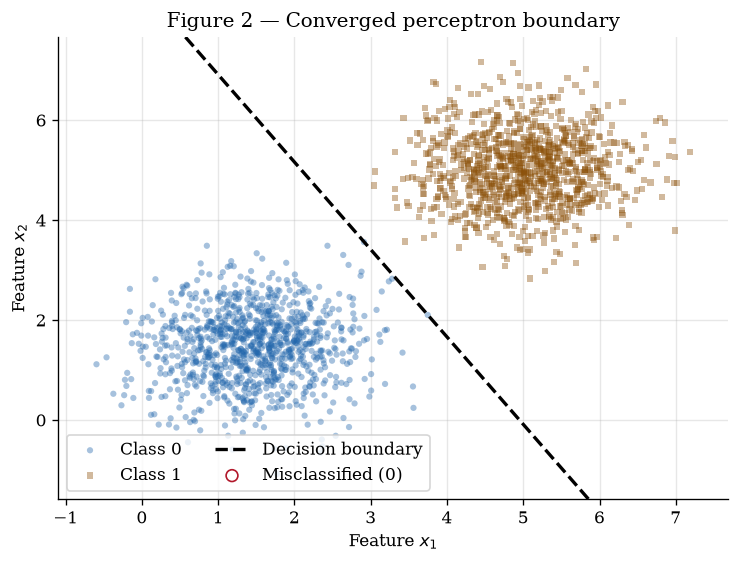

In [6]:
fig, ax = plt.subplots()
scatter_classes(ax, X1, y1, alpha=0.4)
xlim = (X1[:, 0].min() - 0.5, X1[:, 0].max() + 0.5)
ylim = (X1[:, 1].min() - 0.5, X1[:, 1].max() + 0.5)
ax.plot(*boundary_segment(result_001.weights, result_001.bias, xlim, ylim),
        'k--', linewidth=2, label='Decision boundary')
wrong_1 = Perceptron.predict(X1, result_001.weights, result_001.bias) != y1
ax.scatter(X1[wrong_1, 0], X1[wrong_1, 1], s=50, facecolors='none',
           edgecolors='#B2182B', label=f'Misclassified ({wrong_1.sum()})')
ax.set(xlim=xlim, ylim=ylim, title='Figure 2 — Converged perceptron boundary',
       xlabel=r'Feature $x_1$', ylabel=r'Feature $x_2$')
ax.legend(ncols=2)
plt.show()

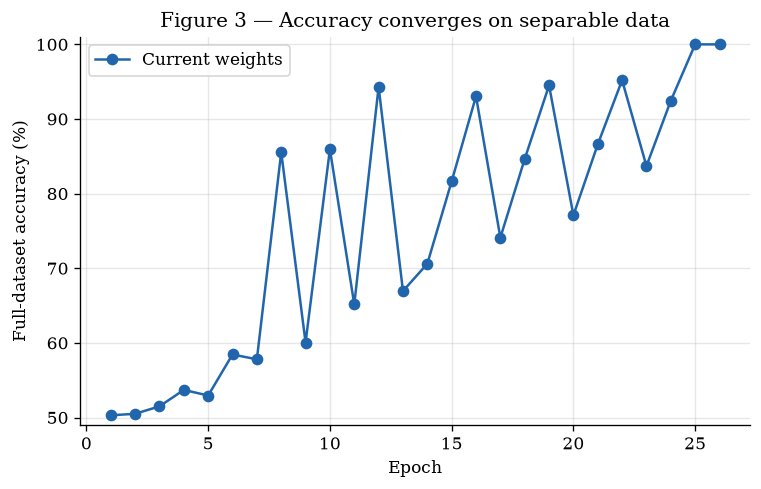

In [7]:
epochs_1 = np.arange(1, result_001.epochs + 1)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(epochs_1, np.array(result_001.accuracy_history) * 100,
        color=COLORS[0], marker='o', label='Current weights')
ax.set(title='Figure 3 — Accuracy converges on separable data',
       xlabel='Epoch', ylabel='Full-dataset accuracy (%)', ylim=(49, 101))
ax.legend()
plt.show()

### D — Analysis

The online accuracy is not monotone because correcting one point can temporarily break another. The update-count envelope nevertheless contracts until epoch 26 makes zero corrections. Linear separability with a positive margin is the assumption that lets the perceptron convergence theorem guarantee finitely many mistakes.

In [8]:
direction_001 = result_001.weights / np.linalg.norm(result_001.weights)
direction_1 = result_1.weights / np.linalg.norm(result_1.weights)
cosine = np.clip(direction_001 @ direction_1, -1.0, 1.0)
angle = np.degrees(np.arccos(cosine))
offset_001 = -result_001.bias / np.linalg.norm(result_001.weights)
offset_1 = -result_1.bias / np.linalg.norm(result_1.weights)

print('eta=1.0 final weights:', np.round(result_1.weights, 6))
print(f'eta=1.0 bias: {result_1.bias:.6f}')
print(f'Epochs: {result_1.epochs} | accuracy: {result_1.accuracy_history[-1]:.2%}')
print('Normalized directions:', np.round(direction_001, 6), np.round(direction_1, 6))
print(f'Cosine: {cosine:.8f} | angle: {angle:.5f} degrees')
print(f'Boundary offsets: {offset_001:.3f} and {offset_1:.3f}')

eta=1.0 final weights: [5.870616 3.359239]
eta=1.0 bias: -31.000000
Epochs: 37 | accuracy: 100.00%
Normalized directions: [0.868123 0.496349] [0.86795  0.496652]
Cosine: 0.99999994 | angle: 0.01998 degrees
Boundary offsets: 4.298 and 4.583


With $\eta=1$, one update overwhelms the small initialization; with $\eta=0.01$, early updates are comparable to it. In this seeded run the normals happen to be almost parallel, but their offsets differ.

**Zero-start argument.** From $\mathbf{w}=0,b=0$, after $k$ updates,
$\mathbf{w}^{(k)}_\eta=\eta\sum_i e_i\mathbf{x}_i$ and $b^{(k)}_\eta=\eta\sum_i e_i$. Two positive learning rates therefore produce parameters related by the factor $\eta_2/\eta_1$. Positive scaling preserves every prediction, hence every following error and update by induction. The boundaries and epoch counts would be identical, which is why the non-zero initialization matters.

---
## Exercise 2 — Overlapping data

### A — Generate the data

Class means are now $[3,3]$ and $[4,4]$, with covariance $\operatorname{diag}(1.5,1.5)$. The distributions overlap, violating the separability assumption. The same generator continues from Exercise 1.

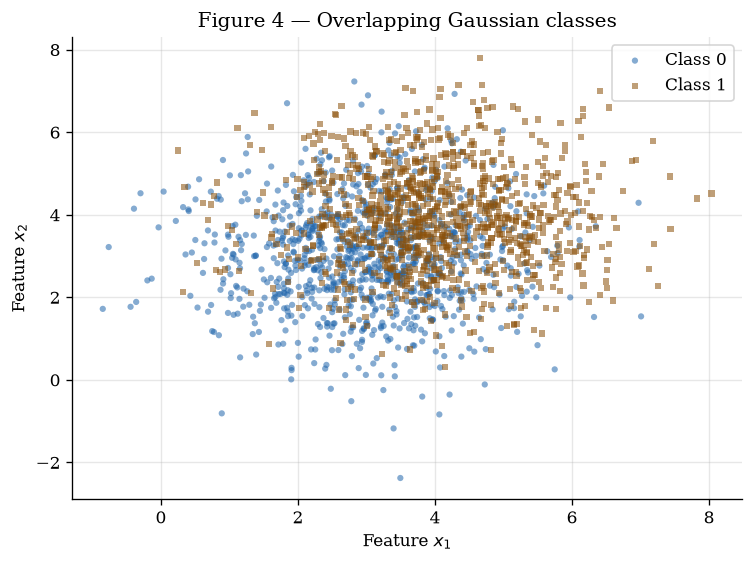

In [9]:
covariance_2 = np.array([[1.5, 0.0], [0.0, 1.5]])
class_0_overlap = rng.multivariate_normal([3.0, 3.0], covariance_2, size=1000)
class_1_overlap = rng.multivariate_normal([4.0, 4.0], covariance_2, size=1000)
X2 = np.vstack([class_0_overlap, class_1_overlap])
y2 = np.r_[np.zeros(1000, dtype=int), np.ones(1000, dtype=int)]

fig, ax = plt.subplots()
scatter_classes(ax, X2, y2)
ax.set(title='Figure 4 — Overlapping Gaussian classes',
       xlabel=r'Feature $x_1$', ylabel=r'Feature $x_2$')
ax.legend()
plt.show()

### B — Train, keeping the best weights

The model and loop are unchanged. Only the dataset and newly prescribed random initialization differ. The pocket retains a copy whenever an update yields a strict improvement in full-dataset accuracy.

In [10]:
initial_2 = initialize_weights(rng, 2)
result_2 = Perceptron(learning_rate=0.01, max_epochs=100).fit(X2, y2, initial_2)
final_accuracy_2 = Perceptron.accuracy(X2, y2, result_2.weights, result_2.bias)
centroid = X2.mean(axis=0)
final_norm = np.linalg.norm(result_2.weights)
pocket_norm = np.linalg.norm(result_2.pocket_weights)
final_predictions = Perceptron.predict(X2, result_2.weights, result_2.bias)
pocket_predictions = Perceptron.predict(X2, result_2.pocket_weights, result_2.pocket_bias)
final_centroid_distance = abs(result_2.weights @ centroid + result_2.bias) / final_norm
pocket_centroid_distance = abs(result_2.pocket_weights @ centroid + result_2.pocket_bias) / pocket_norm
mean_sample_norm = np.mean(np.linalg.norm(X2, axis=1))

print('Initial weights:', np.round(initial_2, 6))
print('Final weights:', np.round(result_2.weights, 6), f'| bias: {result_2.bias:.6f}')
print(f'Final accuracy: {final_accuracy_2:.2%}')
print('Pocket weights:', np.round(result_2.pocket_weights, 6), f'| bias: {result_2.pocket_bias:.6f}')
print(f'Pocket accuracy: {result_2.pocket_accuracy:.2%}')
print(f'Pocket best: epoch {result_2.pocket_epoch}, update {result_2.pocket_update}')
print(f'Epochs: {result_2.epochs} | total updates: {result_2.total_updates}')

Initial weights: [ 0.012158 -0.00451 ]
Final weights: [0.054484 0.048043] | bias: -0.070000
Final accuracy: 50.15%
Pocket weights: [0.010664 0.008727] | bias: -0.070000
Pocket accuracy: 71.10%
Pocket best: epoch 86, update 247
Epochs: 100 | total updates: 289


### C — Final and pocket boundaries

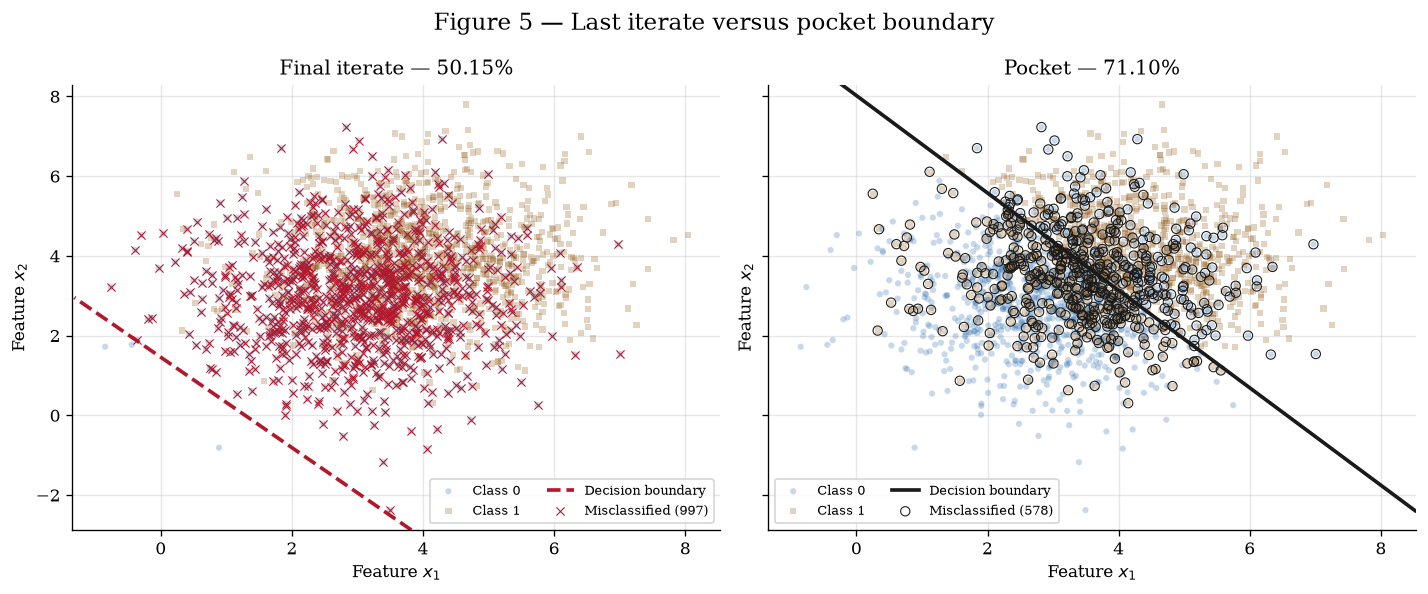

In [11]:
xlim_2 = (X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5)
ylim_2 = (X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5)
final_wrong = final_predictions != y2
pocket_wrong = pocket_predictions != y2
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
panels = [
    (axes[0], result_2.weights, result_2.bias, final_wrong, '#B2182B', 'x',
     f'Final iterate — {final_accuracy_2:.2%}', '--'),
    (axes[1], result_2.pocket_weights, result_2.pocket_bias, pocket_wrong, '#1a1a1a', 'o',
     f'Pocket — {result_2.pocket_accuracy:.2%}', '-'),
]
for ax, weights, bias, wrong, color, marker, title, linestyle in panels:
    scatter_classes(ax, X2, y2, alpha=0.25)
    ax.plot(*boundary_segment(weights, bias, xlim_2, ylim_2), color=color,
            linestyle=linestyle, linewidth=2.2, label='Decision boundary')
    if marker == 'x':
        ax.scatter(X2[wrong, 0], X2[wrong, 1], s=24, marker=marker, color=color,
                   linewidths=0.65, label=f'Misclassified ({wrong.sum()})')
    else:
        ax.scatter(X2[wrong, 0], X2[wrong, 1], s=31, marker=marker, facecolors='none',
                   edgecolors=color, linewidths=0.65, label=f'Misclassified ({wrong.sum()})')
    ax.set(xlim=xlim_2, ylim=ylim_2, title=title,
           xlabel=r'Feature $x_1$', ylabel=r'Feature $x_2$')
    ax.legend(fontsize=8, ncols=2)
fig.suptitle('Figure 5 — Last iterate versus pocket boundary', fontsize=14)
fig.tight_layout()
plt.show()

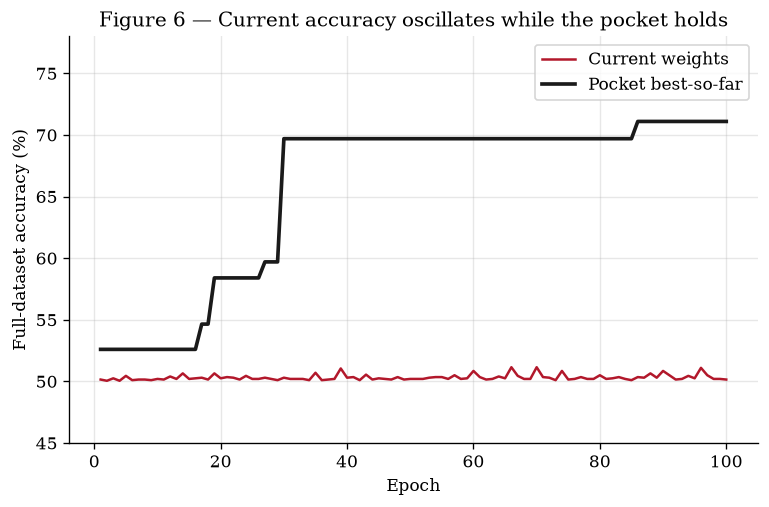

In [12]:
epochs_2 = np.arange(1, result_2.epochs + 1)
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(epochs_2, np.array(result_2.accuracy_history) * 100,
        color='#B2182B', label='Current weights')
ax.plot(epochs_2, np.array(result_2.pocket_accuracy_history) * 100,
        color='#1a1a1a', linewidth=2.2, label='Pocket best-so-far')
ax.set(title='Figure 6 — Current accuracy oscillates while the pocket holds',
       xlabel='Epoch', ylabel='Full-dataset accuracy (%)', ylim=(45, 78))
ax.legend()
plt.show()

### D — Analysis

The next cell verifies the mechanism numerically. A mistake moves $b$ by $\eta=0.01$, but moves the weight vector by about $\eta\lVert\mathbf{x}\rVert\approx0.051$. The final boundary is pushed away from the cloud and predicts almost everything as class 1; the pocket boundary remains near the centroid and splits its predictions between the classes.

In [13]:
print(f'Mean ||x||: {mean_sample_norm:.4f}')
print(f'Typical weight step: {0.01 * mean_sample_norm:.4f} | bias step: 0.0100')
print(f'Final ||w||: {final_norm:.5f} | b: {result_2.bias:.5f}')
print(f'Final centroid distance: {final_centroid_distance:.5f}')
print('Final predicted balance:', np.bincount(final_predictions).tolist())
print(f'Pocket ||w||: {pocket_norm:.5f}')
print(f'Pocket centroid distance: {pocket_centroid_distance:.5f}')
print('Pocket predicted balance:', np.bincount(pocket_predictions).tolist())

Mean ||x||: 5.1108
Typical weight step: 0.0511 | bias step: 0.0100
Final ||w||: 0.07264 | b: -0.07000
Final centroid distance: 3.97865
Final predicted balance: [3, 1997]
Pocket ||w||: 0.01378
Pocket centroid distance: 0.15115
Pocket predicted balance: [1088, 912]


The convergence theorem does not apply because the overlapping data are not linearly separable with a positive margin. More epochs keep chasing incompatible points, and a smaller $\eta$ rescales both $\Delta b$ and $\Delta\mathbf{w}$ without changing their imbalance or creating a separating line. The pocket helps because it returns the best visited state instead of the arbitrary last one.

---
## Results summary

In [14]:
summary = pd.DataFrame([
    [1, r'Exercise 1 — final w and b', f'w={result_001.weights.round(6).tolist()}, b={result_001.bias:.6f}'],
    [2, 'Exercise 1 — epochs to convergence', result_001.epochs],
    [3, 'Exercise 1 — final accuracy', f'{result_001.accuracy_history[-1]:.2%}'],
    [4, 'Exercise 1 — epochs and accuracy with eta=1.0', f'{result_1.epochs} epochs; {result_1.accuracy_history[-1]:.2%}'],
    [5, r'Exercise 2 — final w and b', f'w={result_2.weights.round(6).tolist()}, b={result_2.bias:.6f}'],
    [6, 'Exercise 2 — final accuracy', f'{final_accuracy_2:.2%}'],
    [7, 'Exercise 2 — pocket accuracy', f'{result_2.pocket_accuracy:.2%}'],
    [8, 'Exercise 2 — pocket best epoch', result_2.pocket_epoch],
], columns=['#', 'Quantity', 'Value'])
summary

,#,Quantity,Value
0,1,Exercise 1 — final w and b,"w=[0.050497, 0.028872], b=-0.250000"
1,2,Exercise 1 — epochs to convergence,26
2,3,Exercise 1 — final accuracy,100.00%
3,4,Exercise 1 — epochs and accuracy with eta=1.0,37 epochs; 100.00%
4,5,Exercise 2 — final w and b,"w=[0.054484, 0.048043], b=-0.070000"
5,6,Exercise 2 — final accuracy,50.15%
6,7,Exercise 2 — pocket accuracy,71.10%
7,8,Exercise 2 — pocket best epoch,86
